# Getting data

In [77]:
import kagglehub

path = kagglehub.dataset_download("jamaltariqcheema/pima-indians-diabetes-dataset")
print("Path to dataset files:", path)

Path to dataset files: /home/ojke/.cache/kagglehub/datasets/jamaltariqcheema/pima-indians-diabetes-dataset/versions/1


In [78]:
from pathlib import Path
import pandas as pd

pd.set_option('display.width', 140)

df = pd.read_csv(Path(path) / "diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76.0,48,180.0,32.9,0.171,63,0
764,2,122,70.0,27,102.5,36.8,0.340,27,0
765,5,121,72.0,23,112.0,26.2,0.245,30,0
766,1,126,60.0,32,169.5,30.1,0.349,47,1


In [79]:
X = df.copy().drop(columns=["Outcome"])
y = df["Outcome"]

In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, shuffle=True)

# Common Loss function

In [81]:
from sklearn.metrics import mean_absolute_error

# Decision Tree

[Text(0.44560185185185186, 0.9375, 'x[4] <= 121.0\ngini = 0.452\nsamples = 576\nvalue = [377, 199]'),
 Text(0.2361111111111111, 0.8125, 'x[1] <= 151.5\ngini = 0.121\nsamples = 324\nvalue = [303, 21]'),
 Text(0.3408564814814815, 0.875, 'True  '),
 Text(0.17592592592592593, 0.6875, 'x[5] <= 50.9\ngini = 0.086\nsamples = 310\nvalue = [296, 14]'),
 Text(0.1574074074074074, 0.5625, 'x[4] <= 109.0\ngini = 0.081\nsamples = 309\nvalue = [296, 13]'),
 Text(0.09259259259259259, 0.4375, 'x[3] <= 40.5\ngini = 0.054\nsamples = 289\nvalue = [281, 8]'),
 Text(0.05555555555555555, 0.3125, 'x[4] <= 98.0\ngini = 0.036\nsamples = 273\nvalue = [268, 5]'),
 Text(0.037037037037037035, 0.1875, 'x[4] <= 95.5\ngini = 0.104\nsamples = 91\nvalue = [86, 5]'),
 Text(0.018518518518518517, 0.0625, 'gini = 0.085\nsamples = 90\nvalue = [86, 4]'),
 Text(0.05555555555555555, 0.0625, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.07407407407407407, 0.1875, 'gini = 0.0\nsamples = 182\nvalue = [182, 0]'),
 Text(0.1296

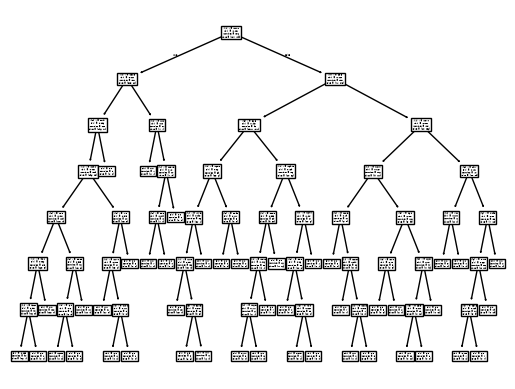

In [89]:
from sklearn import tree

diabetes_tree = tree.DecisionTreeClassifier(max_depth=7)
diabetes_tree = diabetes_tree.fit(X_train, y_train)
tree.plot_tree(diabetes_tree)

In [91]:
preds = diabetes_tree.predict(X_test)
mean_absolute_error(y_test, preds)

0.140625

# Random Forest

In [93]:
from numpy.random import default_rng

def get_tree(X, y, train_ratio=0.75):
    rng = default_rng()
    train_len = int(len(X) * train_ratio)
    train_idxs = rng.choice(len(X), size=train_len, replace=False)
    X_train, y_train = X.iloc[train_idxs], y.iloc[train_idxs]
    next_tree = tree.DecisionTreeClassifier(max_depth=7)
    next_tree.fit(X_train, y_train)
    return next_tree

In [94]:
NUM_TREES = 100
trees = [get_tree(X_train, y_train) for _ in range(NUM_TREES)]

In [95]:
import numpy as np

preds = [t.predict(X_test) for t in trees]
forest_preds = np.stack(preds).mean(0)
mean_absolute_error(y_test, forest_preds)

0.16458333333333333

In [96]:
from sklearn.ensemble import RandomForestClassifier

sk_forest = RandomForestClassifier(NUM_TREES, max_depth=7)
sk_forest.fit(X_train, y_train)
mean_absolute_error(y_test, sk_forest.predict(X_test))

0.15104166666666666

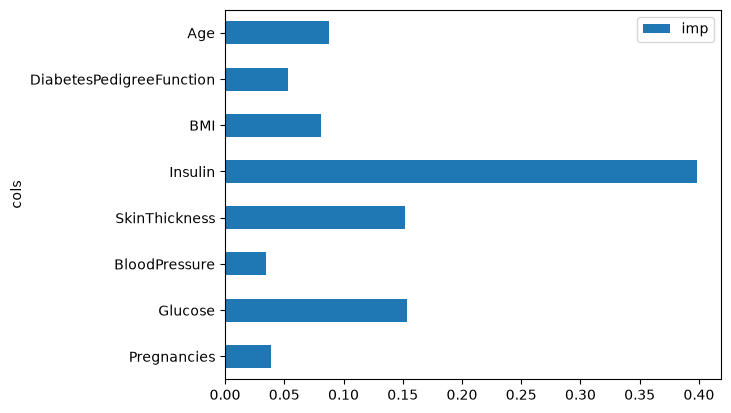

In [97]:
pd.DataFrame(dict(cols=X_train.columns, imp=sk_forest.feature_importances_)).plot('cols', 'imp', 'barh');

# SVM Classifier (SVC)

### No specified kernel

In [102]:
from sklearn import svm

diabetes_svc = svm.SVC()
diabetes_svc.fit(X_train, y_train)
preds = diabetes_svc.predict(X_test)
mean_absolute_error(y_test, preds)

0.171875

### Polynomial kernels

In [107]:
def make_poly_svc(degree, X, y):
    model = svm.SVC(kernel="poly", degree=degree)
    model.fit(X, y)
    return model

degrees = range(2, 8)
poly_svcs = [make_poly_svc(d, X_train, y_train) for d in degrees]
preds = [poly_svc.predict(X_test) for poly_svc in poly_svcs]
for degree, pred in zip(degrees, preds):
    current_loss = mean_absolute_error(y_test, pred)
    print(f"{degree:}: loss = {current_loss:>20}")

2: loss =             0.171875
3: loss =  0.16145833333333334
4: loss =  0.16666666666666666
5: loss =              0.15625
6: loss =              0.15625
7: loss =              0.15625


### RBF kernels

In [117]:
def make_rbf_svc(gamma, X, y):
    model = svm.SVC(kernel="rbf", gamma=gamma)
    model.fit(X, y)
    return model

gammas = [0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10]
rfb_svcs = [make_rbf_svc(g, X_train, y_train) for g in gammas]
preds = [rbf_svc.predict(X_test) for rbf_svc in rfb_svcs]
for gamma, pred in zip(gammas, preds):
    current_loss = mean_absolute_error(y_test, pred)
    print(f"{gamma:>10}: loss = {current_loss:>20}")


     1e-05: loss =  0.16145833333333334
    0.0001: loss =  0.16666666666666666
     0.001: loss =             0.171875
      0.01: loss =  0.22395833333333334
       0.1: loss =             0.359375
         1: loss =             0.359375
        10: loss =             0.359375


### GridSearchCV with scaling

In [124]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

params = {'kernel':('linear', 'poly', 'rbf', 'sigmoid')}
svc = svm.SVC()
clf = make_pipeline(StandardScaler(), GridSearchCV(svc, params))
clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('gridsearchcv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Pregnancies','Glucose','BloodPressure',...,'BMI', 'DiabetesPedigreeFunction','Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [125]:
preds = clf.predict(X_test)
mean_absolute_error(y_test, preds)

0.1875